In [150]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from uncertainties import ufloat, ufloat_fromstr
import seaborn as sns
import re
import os

In [151]:
# Define paths for abatement cost data

notebook_dir = os.path.dirname(os.path.abspath("__file__"))
file_path_gwp_star_saf = os.path.join(notebook_dir, '../outputs/GWP_star_abatement_cost_saf.csv')
file_path_gwp_20_saf = os.path.join(notebook_dir, '../outputs/GWP20_abatement_cost_saf.csv')
file_path_gwp_100_saf = os.path.join(notebook_dir, '../outputs/GWP100_abatement_cost_saf.csv')

file_path_gwp_star_daccs = os.path.join(notebook_dir, '../outputs/GWP_star_abatement_cost_daccs.csv')
file_path_gwp_20_daccs = os.path.join(notebook_dir, '../outputs/GWP20_abatement_cost_daccs.csv')
file_path_gwp_100_daccs = os.path.join(notebook_dir, '../outputs/GWP100_abatement_cost_daccs.csv')


In [152]:
# Read abatement cost data

abatement_cost_gwp_star_saf = pd.read_csv(file_path_gwp_star_saf)
abatement_cost_gwp_20_saf = pd.read_csv(file_path_gwp_20_saf)
abatement_cost_gwp_100_saf = pd.read_csv(file_path_gwp_100_saf)

abatement_cost_gwp_star_daccs = pd.read_csv(file_path_gwp_star_daccs)
abatement_cost_gwp_20_daccs = pd.read_csv(file_path_gwp_20_daccs)
abatement_cost_gwp_100_daccs = pd.read_csv(file_path_gwp_100_daccs)

In [153]:

abatement_cost_gwp_star_saf.loc[:,"24"]= abatement_cost_gwp_star_saf.loc[:,"24"].apply(lambda x: ufloat_fromstr(x)) # Converts ufloats from string
abatement_cost_gwp_star_daccs.loc[:,"24"] = abatement_cost_gwp_star_daccs.loc[:,"24"].apply(lambda x: ufloat_fromstr(x))
abatement_cost_gwp_star_saf[["Abatement Cost Low", "Abatement Cost High", "Abatement Cost Nominal", "Standard Deviation"]] = abatement_cost_gwp_star_saf["24"].apply(
    lambda x: pd.Series({
        "Abatement Cost Low": x.nominal_value - x.std_dev,
        "Abatement Cost High": x.nominal_value + x.std_dev,
        "Abatement Cost Average": x.nominal_value,
        "Standard Deviation": x.std_dev
    })
)
abatement_cost_gwp_star_daccs[["Abatement Cost Low", "Abatement Cost High", "Abatement Cost Nominal", "Standard Deviation"]] = abatement_cost_gwp_star_daccs["24"].apply(
    lambda x: pd.Series({
        "Abatement Cost Low": x.nominal_value - x.std_dev,
        "Abatement Cost High": x.nominal_value + x.std_dev,
        "Abatement Cost Average": x.nominal_value,
        "Standard Deviation": x.std_dev
    })
)
abatement_cost_saf_dfs = {"GWP20": abatement_cost_gwp_20_saf, "GWP100": abatement_cost_gwp_100_saf, "GWP*": abatement_cost_gwp_star_saf}
abatement_cost_daccs_dfs = {"GWP20": abatement_cost_gwp_20_daccs, "GWP100": abatement_cost_gwp_100_daccs, "GWP*": abatement_cost_gwp_star_daccs}

In [154]:
for df in abatement_cost_saf_dfs.values():
    df.rename(columns = {'Unnamed: 0':'Quartile', '24': 'Abatement Cost'}, inplace = True)
for df in abatement_cost_daccs_dfs.values():
    df.rename(columns = {'Unnamed: 0':'Quartile', '24': 'Abatement Cost'}, inplace = True)

In [155]:
# GWP abatement cost dfs are those that don't have GWP* in the name
gwp_abatement_cost_saf_dfs = {k: v for k, v in abatement_cost_saf_dfs.items() if "GWP*" not in k}
gwp_abatement_cost_daccs_dfs = {k: v for k, v in abatement_cost_daccs_dfs.items() if "GWP*" not in k}

/var/folders/02/f8g3z62n7qxgc0xv8jd6gf800000gn/T/ipykernel_27942/389833590.py:89: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Patch(color=color_saf, alpha=0.5, edgecolor='black', label="SAF"),
/var/folders/02/f8g3z62n7qxgc0xv8jd6gf800000gn/T/ipykernel_27942/389833590.py:90: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  Patch(color=color_daccs, alpha=0.5, edgecolor='black', label="DACCS"),


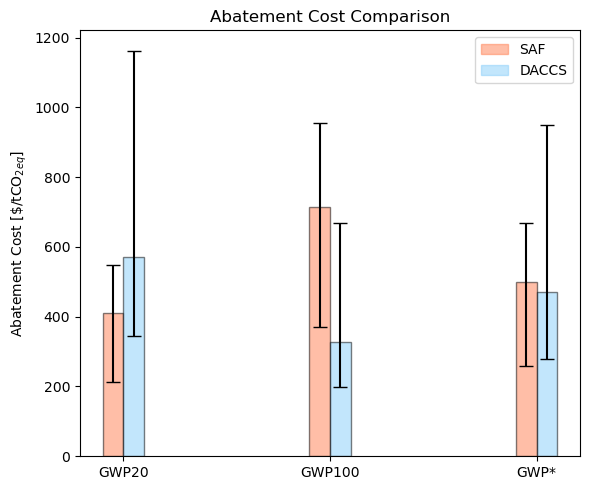

In [156]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 5))  # Adjusted width for additional bars

bar_width = 0.1  # Width of each bar
color_saf = 'coral'  # Color for SAF bars
color_daccs = 'lightskyblue'  # Color for DACCS bars

# Plot SAF bars
for i, (df_name, df) in enumerate(gwp_abatement_cost_saf_dfs.items()):
    # Extract values
    median_cost = df.loc[df["Quartile"] == "50%", "Abatement Cost"].values[0]
    lower_cost = df.loc[df["Quartile"] == "25%", "Abatement Cost"].values[0]
    upper_cost = df.loc[df["Quartile"] == "75%", "Abatement Cost"].values[0]

    # Calculate bar position
    x_position = i

    # Add SAF bar
    ax.bar(
        x_position, median_cost, bar_width, color=color_saf, alpha=0.5, edgecolor='black'
    )
    # Add error bars
    ax.errorbar(
        x_position, median_cost, yerr=[[median_cost - lower_cost], [upper_cost - median_cost]],
        color='black', capsize=5, capthick=1, fmt='none'
    )

# Plot DACCS bars
for i, (df_name, df) in enumerate(gwp_abatement_cost_daccs_dfs.items()):
    # Extract values
    median_cost = df.loc[df["Quartile"] == "50%", "Abatement Cost"].values[0]
    lower_cost = df.loc[df["Quartile"] == "25%", "Abatement Cost"].values[0]
    upper_cost = df.loc[df["Quartile"] == "75%", "Abatement Cost"].values[0]

    # Calculate bar position
    x_position = i + bar_width  # Shift DACCS bar to the right

    # Add DACCS bar
    ax.bar(
        x_position, median_cost, bar_width, color=color_daccs, alpha=0.5, edgecolor='black'
    )
    # Add error bars
    ax.errorbar(
        x_position, median_cost, yerr=[[median_cost - lower_cost], [upper_cost - median_cost]],
        color='black', capsize=5, capthick=1, fmt='none'
    )

# Add the SAF GWP* bar
x_position = len(gwp_abatement_cost_saf_dfs)
abatement_cost_gwp_star_saf.set_index("Quartile", inplace=True)
median_cost = abatement_cost_gwp_star_saf.loc["50%", "Abatement Cost Nominal"]
lower_cost = abatement_cost_gwp_star_saf.loc["25%", "Abatement Cost Nominal"]
upper_cost = abatement_cost_gwp_star_saf.loc["75%", "Abatement Cost Nominal"]

ax.bar(
    x_position, median_cost, bar_width, color=color_saf, alpha=0.5, edgecolor='black'
)
ax.errorbar(
    x_position, median_cost, yerr=[[median_cost - lower_cost], [upper_cost - median_cost]],
    color='black', capsize=5, capthick=1, fmt='none'
)

# Add the DACCS GWP* bar
abatement_cost_gwp_star_daccs.set_index("Quartile", inplace=True)
x_position = len(gwp_abatement_cost_saf_dfs) + bar_width
median_cost = abatement_cost_gwp_star_daccs.loc["50%", "Abatement Cost Nominal"]
lower_cost = abatement_cost_gwp_star_daccs.loc["25%", "Abatement Cost Nominal"]
upper_cost = abatement_cost_gwp_star_daccs.loc["75%", "Abatement Cost Nominal"]

ax.bar(
    x_position, median_cost, bar_width, color=color_daccs, alpha=0.5, edgecolor='black'
)
ax.errorbar(
    x_position, median_cost, yerr=[[median_cost - lower_cost], [upper_cost - median_cost]],
    color='black', capsize=5, capthick=1, fmt='none'
)

# Customize plot
ax.set_xticks(list(range(len(gwp_abatement_cost_saf_dfs))) + [len(gwp_abatement_cost_saf_dfs)])
xtick_labels = list(gwp_abatement_cost_saf_dfs.keys()) + ["GWP*"]
ax.set_xticks([x + bar_width / 2 for x in range(len(xtick_labels))])  # Center ticks
ax.set_xticklabels(xtick_labels)
ax.set_ylabel(r"Abatement Cost [\$/tCO$_{2eq}$]")
ax.set_title("Abatement Cost Comparison")
ax.set_ylim(bottom=0)

# Add legend
custom_legend = [
    Patch(color=color_saf, alpha=0.5, edgecolor='black', label="SAF"),
    Patch(color=color_daccs, alpha=0.5, edgecolor='black', label="DACCS"),
]
ax.legend(handles=custom_legend)

# Adjust layout and show plot
plt.tight_layout()
plt.show()
